In [2]:
import pickle 
import seaborn as sns
import pandas as pd
import shap
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from operator import add
from functools import reduce
from torchvision import models, transforms
from skimage import io
from torch.utils.data import Subset
from model import MultiInputModel
from torch.utils.data import Dataset, DataLoader
import torch
import pandas as pd
import random
from typing import List
from skimage import io
from params import ROOT_DIR
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
import copy


In [3]:
# Custom SHAP plot
def image_plot(shap_values, pixel_values, labels=None, preds=None, names=None, width=20, aspect=0.2, hspace=0.2, labelpad=None, show=True, fig_size=None):
    """ Plots SHAP values for image inputs.
    Parameters
    ----------
    shap_values : [numpy.array]
        List of arrays of SHAP values. Each array has the shap (# samples x width x height x channels), and the
        length of the list is equal to the number of model outputs that are being explained.
    pixel_values : numpy.array
        Matrix of pixel values (# samples x width x height x channels) for each image. It should be the same
        shape as each array in the shap_values list of arrays.
    labels : list
        List of names for each of the model outputs that are being explained. This list should be the same length
        as the shap_values list.
    width : float
        The width of the produced matplotlib plot.
    labelpad : float
        How much padding to use around the model output labels.
    show : bool
        Whether matplotlib.pyplot.show() is called before returning. Setting this to False allows the plot
        to be customized further after it has been created.
    """

    multi_output = True
    if type(shap_values) != list:
        multi_output = False
        shap_values = [shap_values]

    # make sure labels
    if labels is not None:
        assert labels.shape[0] == shap_values[0].shape[0], "Labels must have same row count as shap_values arrays!"
        if multi_output:
            assert labels.shape[1] == len(shap_values), "Labels must have a column for each output in shap_values!"
        else:
            assert len(labels.shape) == 1, "Labels must be a vector for single output shap_values."

    label_kwargs = {} if labelpad is None else {'pad': labelpad}

    # plot our explanations
    x = pixel_values
    if fig_size is None:
        fig_size = np.array([3 * (len(shap_values) + 1), 2.5 * (x.shape[0] + 1)])
        if fig_size[0] > width:
            fig_size *= width / fig_size[0]
    fig, axes = plt.subplots(nrows=x.shape[0], ncols=len(shap_values) + 1, figsize=fig_size)
    if len(axes.shape) == 1:
        axes = axes.reshape(1,axes.size)
    for row in range(x.shape[0]):
        x_curr = x[row].copy()

        # make sure
        if len(x_curr.shape) == 3 and x_curr.shape[2] == 1:
            x_curr = x_curr.reshape(x_curr.shape[:2])
        if x_curr.max() > 1:
            x_curr /= 255.

        # get a grayscale version of the image
        if len(x_curr.shape) == 3 and x_curr.shape[2] == 3:
            x_curr_gray = (0.2989 * x_curr[:,:,0] + 0.5870 * x_curr[:,:,1] + 0.1140 * x_curr[:,:,2]) # rgb to gray
        else:
            x_curr_gray = x_curr

        axes[row,0].imshow(x_curr, cmap=plt.get_cmap('gray'))
        axes[row,0].set_title(f'Image: {names[row]}', **label_kwargs)
        axes[row,0].axis('off')
        if len(shap_values[0][row].shape) == 2:
            abs_vals = np.stack([np.abs(shap_values[i]) for i in range(len(shap_values))], 0).flatten()
        else:
            abs_vals = np.stack([np.abs(shap_values[i].sum(-1)) for i in range(len(shap_values))], 0).flatten()
        max_val = np.nanpercentile(abs_vals, 99.9)
        for i in range(len(shap_values)):
            if labels is not None:
                axes[row,i+1].set_title(f'Label: {labels[row,i]} Pred: {preds[row,i]:.2f}', **label_kwargs)
            sv = shap_values[i][row] if len(shap_values[i][row].shape) == 2 else shap_values[i][row].sum(-1)
            axes[row,i+1].imshow(x_curr_gray, cmap=plt.get_cmap('gray'), alpha=0.15, extent=(-1, sv.shape[1], sv.shape[0], -1))
            im = axes[row,i+1].imshow(sv, cmap=shap.plots.colors.red_transparent_blue, vmin=-max_val, vmax=max_val)
            axes[row,i+1].axis('off')
    if hspace == 'auto':
        fig.tight_layout()
    else:
        fig.subplots_adjust(hspace=hspace)
    cb = fig.colorbar(im, ax=np.ravel(axes).tolist(), label="SHAP value", orientation="horizontal", aspect=fig_size[0]/aspect)
    cb.outline.set_visible(False)
    if show:
        plt.show()

In [4]:
data = pd.read_csv("../data.csv")
features_name = data.iloc[:,5:].columns.values

In [5]:
data.head()

,Patient,label,photo_1,photo_2,eye_side,gender,G,T,TS,NS,...,TS/NS,TS/N,TS/NI,TS/TI,NS/N,NS/NI,NS/TI,N/NI,N/TI,NI/TI
0,ADALCI P SILVA 00002252,1,imgs/ADALCI P SILVA 00002252/111111_Color_11MP...,imgs/ADALCI P SILVA 00002252/111111_Color_11MP...,right,1.0,60,56,74,51,...,1.450980,1.275862,0.948718,1.370370,0.879310,0.653846,0.944444,0.743590,1.074074,1.444444
1,ADAO A SENA 1017456,1,imgs/ADAO A SENA 1017456/111111_Color_11MP_R_0...,imgs/ADAO A SENA 1017456/111111_Color_11MP_R_0...,right,1.0,27,20,39,43,...,0.906977,1.772727,1.300000,2.294118,1.954545,1.433333,2.529412,0.733333,1.294118,1.764706
2,ADAO A SENA 1017456,0,imgs/ADAO A SENA 1017456/111111_Color_11MP_L_0...,imgs/ADAO A SENA 1017456/111111_Color_11MP_L_0...,left,1.0,95,62,121,107,...,1.130841,1.592105,1.000000,0.909774,1.407895,0.884298,0.804511,0.628099,0.571429,0.909774
3,ADAO JOSE ANDRE 01087502,0,imgs/ADAO JOSE ANDRE 01087502/111111_Color_11M...,imgs/ADAO JOSE ANDRE 01087502/111111_Color_11M...,right,1.0,102,52,136,153,...,0.888889,2.158730,0.937931,0.894737,2.428571,1.055172,1.006579,0.434483,0.414474,0.953947
4,ADAO JOSE ANDRE 01087502,0,imgs/ADAO JOSE ANDRE 01087502/111111_Color_11M...,imgs/ADAO JOSE ANDRE 01087502/111111_Color_11M...,left,1.0,92,50,127,143,...,0.888112,2.116667,1.104348,0.992188,2.383333,1.243478,1.117188,0.521739,0.468750,0.898438


In [6]:
def create_df_results(dict_results, model_name):
    val_auc_history = dict_results["fold_val_auc_history"]
    val_sensitivity_history = dict_results["fold_val_sensitivity_history"]
    val_specificity_history = dict_results["fold_val_specificity_history"]
    val_acc_history = dict_results["fold_val_acc_history"]
    flatten_list_auc = reduce(add, val_auc_history)
    flatten_list_acc = reduce(add, val_acc_history)
    flatten_list_sensitivity = reduce(add, val_sensitivity_history)
    flatten_list_specificity = reduce(add, val_specificity_history)
    df_results_auc = pd.DataFrame(flatten_list_auc, columns=["auc"])
    df_results_sen = pd.DataFrame(flatten_list_sensitivity, columns=["sensitivity"])
    df_results_spe = pd.DataFrame(flatten_list_specificity, columns=["specificity"])
    df_results_acc = pd.DataFrame(flatten_list_acc, columns=["acc"])
   
    
    df_results = pd.concat([df_results_auc, df_results_acc, df_results_sen, df_results_spe], axis=1)
    df_results["model"] = model_name
    df_results["epochs"] = list(range(50)) * 5
    
    return df_results


In [7]:
def new_create_df_results(dict_results, model_name):
    val_auc_history = dict_results["val_auc_history"]
    val_sensitivity_history = dict_results["val_sensitivity_history"]
    val_specificity_history = dict_results["val_specificity_history"]
    val_acc_history = dict_results["val_acc_history"]
    flatten_list_auc = reduce(add, val_auc_history)
    flatten_list_acc = reduce(add, val_acc_history)
    flatten_list_sensitivity = reduce(add, val_sensitivity_history)
    flatten_list_specificity = reduce(add, val_specificity_history)
    df_results_auc = pd.DataFrame(flatten_list_auc, columns=["auc"])
    df_results_sen = pd.DataFrame(flatten_list_sensitivity, columns=["sensitivity"])
    df_results_spe = pd.DataFrame(flatten_list_specificity, columns=["specificity"])
    df_results_acc = pd.DataFrame(flatten_list_acc, columns=["acc"])
   
    
    df_results = pd.concat([df_results_auc, df_results_acc, df_results_sen, df_results_spe], axis=1)
    df_results["model"] = model_name
    df_results["epochs"] = list(range(50)) * 5
    
    return df_results


# Summary 

In [27]:
summary = pd.read_csv("../model_summary.csv",sep=";")

In [28]:
summary.head()

,model_id,model_name,k_fold,frac_val,best_acc,best_auc,best_sp,best_sn,avg_acc,avg_auc,avg_sp,avg_sn,host_name,optim,lr,multi,double_img,backbone
0,f3c3ecbd8d6648359db1050dbe4c4d8c,regnet_single_intput_k_fold,5,NaN,0.834437,0.802889,1.000000,0.795455,0.777714,0.671940,0.913844,0.430035,loki,adam,0.0001,0,0,regnet
1,c6e7ec4615c24683ad480b04389d3a60,regnet_single_intput_k_fold,5,NaN,0.763158,0.524345,1.000000,0.106383,0.718149,0.500634,0.997189,0.004079,loki,sgd,0.0001,0,0,regnet
2,7adbc504a0364f3f89eb61f6e32f9932,regnet_single_intput_k_fold,5,NaN,0.763158,0.679753,0.990654,0.957447,0.634012,0.548345,0.736640,0.360050,loki,ranger,0.0001,0,0,regnet
3,cf2ffba9bb924e5b8290f098ba698961,regnet_single_intput_k_fold,5,NaN,0.794702,0.674918,0.990654,0.914894,0.682178,0.570223,0.820975,0.319470,loki,radam,0.0001,0,0,regnet
4,cae395ff5b3943d594746cda22c8d2a0,mobile_single_intput_k_fold,5,NaN,0.834437,0.735981,1.000000,0.500000,0.755119,0.600135,0.955988,0.244283,loki,adam,0.0001,0,0,mobile


In [29]:
summary[summary['best_sn'] == 1.0]

,model_id,model_name,k_fold,frac_val,best_acc,best_auc,best_sp,best_sn,avg_acc,avg_auc,avg_sp,avg_sn,host_name,optim,lr,multi,double_img,backbone
8,fe12e33d56284321861e222cd62f970e,shuffle_single_intput_k_fold,5,NaN,0.763158,0.500000,1.0,1.0,0.711394,0.500000,0.980000,0.020000,loki,sgd,0.0001,0,0,shuffle
9,778b15e33cb04b71a90e6586f8892c7e,shuffle_single_intput_k_fold,5,NaN,0.763158,0.528803,1.0,1.0,0.709026,0.501974,0.971904,0.032044,loki,adam,0.0001,0,0,shuffle
10,107b69fc4bd2488aa7d675862a8cd29a,shuffle_single_intput_k_fold,5,NaN,0.763158,0.529418,1.0,1.0,0.685239,0.502175,0.911252,0.093098,loki,radam,0.0001,0,0,shuffle
11,d1000a12f3ef4f00b45a3be5fed1b0ac,shuffle_single_intput_k_fold,5,NaN,0.763158,0.540098,1.0,1.0,0.668576,0.500463,0.870596,0.130330,loki,ranger,0.0001,0,0,shuffle
16,4e18c7fc3d014f4bb4869aae84163f76,shuffle_single_intput_k_fold,5,NaN,0.763158,0.528803,1.0,1.0,0.709026,0.501974,0.971904,0.032044,loki,adam,0.0001,0,0,shuffle
17,3c60a216a3904285bb34163923b3ed9b,shuffle_single_intput_k_fold,5,NaN,0.763158,0.500000,1.0,1.0,0.711394,0.500000,0.980000,0.020000,loki,sgd,0.0001,0,0,shuffle
18,e0f4e326a6704bcda89eb091bf69ad2b,shuffle_single_intput_k_fold,5,NaN,0.763158,0.529418,1.0,1.0,0.685239,0.502175,0.911252,0.093098,loki,radam,0.0001,0,0,shuffle
19,1b43d956a0a642a29706ae627765d708,shuffle_single_intput_k_fold,5,NaN,0.763158,0.540098,1.0,1.0,0.668576,0.500463,0.870596,0.130330,loki,ranger,0.0001,0,0,shuffle
29,38be5ad6d6e64b8d98d8940d0239519b,shuffle_single_intput_k_fold,5,NaN,0.769737,0.534670,1.0,1.0,0.693967,0.503361,0.935508,0.071214,loki,adam,0.0010,0,0,shuffle
30,ac8955c566e34be395853a413a7b356d,shuffle_single_intput_k_fold,5,NaN,0.763158,0.571195,1.0,1.0,0.682018,0.505646,0.905684,0.105609,loki,radam,0.0010,0,0,shuffle


In [30]:
summary["feature_extract"] = False

In [32]:
summary.to_csv("../model_summary.csv",index=False)

In [30]:
with open('../models/bk_models/regnet_multi_input_k_fold.pkl', 'rb') as handle:
    dict_results_multi = pickle.load(handle)

with open('../models/bk_models/regnet_single_intput_k_fold.pkl', 'rb') as handle:
    dict_results_single = pickle.load(handle)

with open('../models/regnet_multi_input_double_img_non_k_fold.pkl', 'rb') as handle:
    dict_results_multi_double = pickle.load(handle)

In [31]:
df_results_multi = create_df_results(dict_results_multi,"multi_input")
df_results_single = create_df_results(dict_results_single,"single_input")
df_results_multi_double = new_create_df_results(dict_results_multi_double,"multi_double_input")

ValueError: Length of values (250) does not match length of index (50)

In [21]:
df_results_multi.head()

,auc,acc,sensitivity,specificity,model,epochs
0,0.585129,0.677632,0.372093,0.798165,multi_input,0
1,0.553552,0.743421,0.116279,0.990826,multi_input,1
2,0.549285,0.717105,0.162791,0.935780,multi_input,2
3,0.598250,0.736842,0.279070,0.917431,multi_input,3
4,0.560593,0.743421,0.139535,0.981651,multi_input,4


In [22]:
df_results_single.head()

,auc,acc,sensitivity,specificity,model,epochs
0,0.593983,0.710526,0.325581,0.862385,single_input,0
1,0.654897,0.717105,0.511628,0.798165,single_input,1
2,0.677832,0.750000,0.511628,0.844037,single_input,2
3,0.638041,0.743421,0.395349,0.880734,single_input,3
4,0.685513,0.710526,0.627907,0.743119,single_input,4


In [23]:
df_results_multi_double

,auc,acc,sensitivity,specificity,model,epochs
0,0.579582,0.730263,0.232558,0.926606,multi_double_input,0
1,0.609878,0.743421,0.302326,0.917431,multi_double_input,1
2,0.688287,0.684211,0.697674,0.678899,multi_double_input,2
3,0.570087,0.736842,0.186047,0.954128,multi_double_input,3
4,0.638361,0.723684,0.441860,0.834862,multi_double_input,4
...,...,...,...,...,...,...
245,0.755626,0.807947,0.617021,0.894231,multi_double_input,45
246,0.741203,0.788079,0.617021,0.865385,multi_double_input,46
247,0.766264,0.814570,0.638298,0.894231,multi_double_input,47
248,0.720642,0.807947,0.489362,0.951923,multi_double_input,48


In [24]:
df_results = pd.concat([df_results_single,df_results_multi, df_results_multi_double])
df_results.reset_index(inplace=True)

In [25]:
df_results.shape

(750, 7)

In [26]:
df_results

,index,auc,acc,sensitivity,specificity,model,epochs
0,0,0.593983,0.710526,0.325581,0.862385,single_input,0
1,1,0.654897,0.717105,0.511628,0.798165,single_input,1
2,2,0.677832,0.750000,0.511628,0.844037,single_input,2
3,3,0.638041,0.743421,0.395349,0.880734,single_input,3
4,4,0.685513,0.710526,0.627907,0.743119,single_input,4
...,...,...,...,...,...,...,...
745,245,0.755626,0.807947,0.617021,0.894231,multi_double_input,45
746,246,0.741203,0.788079,0.617021,0.865385,multi_double_input,46
747,247,0.766264,0.814570,0.638298,0.894231,multi_double_input,47
748,248,0.720642,0.807947,0.489362,0.951923,multi_double_input,48


<AxesSubplot:xlabel='epochs', ylabel='auc'>

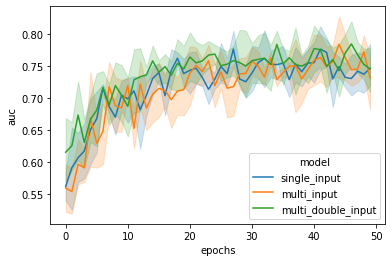

In [27]:
sns.lineplot(data=df_results, x="epochs", y="auc", hue="model")

<AxesSubplot:xlabel='epochs', ylabel='sensitivity'>

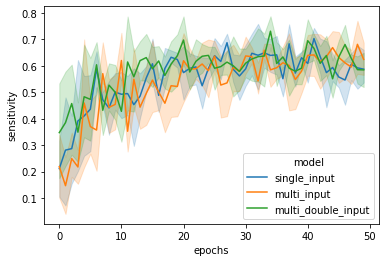

In [28]:
sns.lineplot(data=df_results, x="epochs", y="sensitivity", hue="model")

<AxesSubplot:xlabel='epochs', ylabel='specificity'>

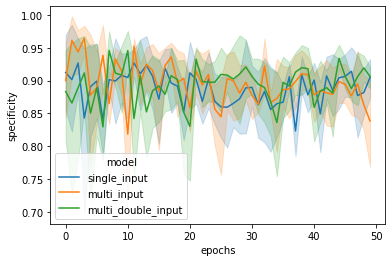

In [29]:
sns.lineplot(data=df_results, x="epochs", y="specificity", hue="model")

<AxesSubplot:xlabel='epochs', ylabel='acc'>

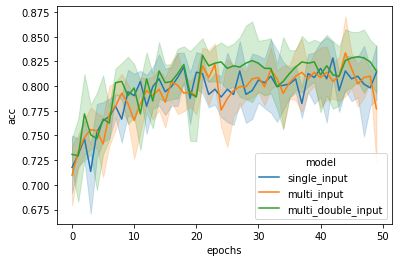

In [30]:
sns.lineplot(data=df_results, x="epochs", y="acc", hue="model")

In [35]:
df_results.loc[df_results['sensitivity'].idxmax()]

index                    82
auc                0.796935
acc                0.763158
sensitivity        0.861111
specificity        0.732759
model          single_input
epochs                   32
Name: 82, dtype: object

# Shap

In [20]:
regnet_multi = models.regnet_y_800mf(False)
features = nn.Sequential(*list(regnet_multi.children()))[:-1]
in_features = 784
ft_size = 8
output_tab = 3
n_classes = 2
features_2 = copy.deepcopy(features)
model = MultiInputModel(
    features, features_2, ft_size, output_tab, in_features
)


In [21]:
model.load_state_dict(torch.load("../models/regnet_multi_input_non_fold_double_img.pth"))

<All keys matched successfully>

In [22]:
dataloader_val = torch.load("../models/val_dataloader_regnet_multi_input_non_fold_double_img.pth")
dataloader_train = torch.load("../models/train_dataloader_regnet_multi_input_non_fold_double_img.pth")

In [23]:
len(dataloader_val.dataset)

157

In [24]:
len(dataloader_train.dataset)

601

In [25]:
num_train_examples = len(dataloader_train.dataset)
num_val_examples = len(dataloader_val.dataset)
background_train = Subset(dataloader_train.dataset, np.arange(num_train_examples))
background_val = Subset(dataloader_val.dataset, np.arange(num_val_examples))

In [26]:
sample_train__img_shap_1 = []
sample_test__img_shap_1 = []
sample_train__img_shap_2 = []
sample_test__img_shap_2 = []
sample_train__tab_shap = []
sample_test__tab_shap = []
sample_train_label = []
sample_test_label = []
for i in range(len(background_train)):
    sample_train__img_shap_1.append(background_train[i][0])
    sample_train__img_shap_2.append(background_train[i][1])
    sample_train__tab_shap.append(background_train[i][2])
    sample_train_label.append(background_train[i][3])
for i in range(len(background_val)):
    sample_test__img_shap_1.append(background_val[i][0])
    sample_test__img_shap_2.append(background_val[i][1])
    sample_test__tab_shap.append(background_val[i][2])
    sample_test_label.append(background_val[i][3])

# Try both

In [88]:
total_train_samples = 100
total_test_samples = 50


In [89]:
explainer_multi = shap.DeepExplainer(model, [torch.from_numpy(np.stack(sample_train__img_shap_1[:total_train_samples])),
                                                    torch.from_numpy(np.stack(sample_train__img_shap_2[:total_train_samples])),
                                                    torch.from_numpy(np.stack(sample_train__tab_shap[:total_train_samples]))])

In [90]:
from tqdm import tqdm
shap_list = []
for i in tqdm(range(total_test_samples)):
    img_1 = torch.from_numpy(np.stack(sample_test__img_shap_1[i]))
    img_2 = torch.from_numpy(np.stack(sample_test__img_shap_2[i]))
    tab = torch.from_numpy(np.stack(sample_test__tab_shap[i]))
    img_1 = img_1[None,:]
    img_2 = img_2[None,:]
    tab = tab[None,:]
    single_shaps_values = explainer_multi.shap_values([img_1,img_2,tab])
    shap_list.append(single_shaps_values)
    if i > len(sample_test__img_shap_1):
        break
    


100%|████████████████████████████████████████████████| 50/50 [26:05<00:00, 31.32s/it]


In [91]:
# 0 img_1
# 1 img_2
# 2 tab
tab_shap_list = []
img_1_shap_list = []
img_2_shap_list = []


for i in range(len(shap_list)):
    tab_shap_list.append(shap_list[i][2])
    img_1_shap_list.append(shap_list[i][0])   
    img_2_shap_list.append(shap_list[i][1]) 

In [92]:
tab_shap_values = np.concatenate(tab_shap_list, axis=0)
img_1_shap_values  = np.concatenate(img_1_shap_list, axis=0)
img_2_shap_values  = np.concatenate(img_2_shap_list, axis=0)

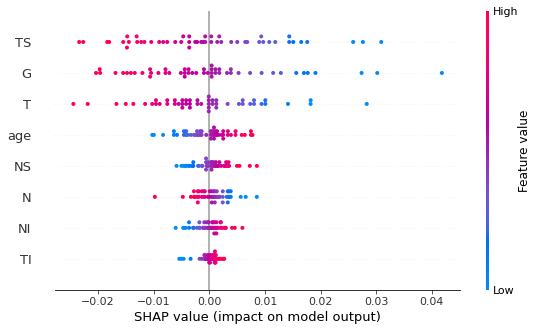

In [93]:
shap.summary_plot(tab_shap_values, np.stack(sample_test__tab_shap[:total_test_samples]), features_name)

In [94]:
swapped_values_img_1 = np.swapaxes(np.swapaxes(img_1_shap_values, 1, -1), 1, 2)
swapped_values_img_2 = np.swapaxes(np.swapaxes(img_2_shap_values, 1, -1), 1, 2)

In [95]:
concat_imgs_img_1 =  np.swapaxes(np.swapaxes(np.stack(sample_test__img_shap_1), 1, -1), 1, 2)
concat_imgs_img_2 =  np.swapaxes(np.swapaxes(np.stack(sample_test__img_shap_2), 1, -1), 1, 2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

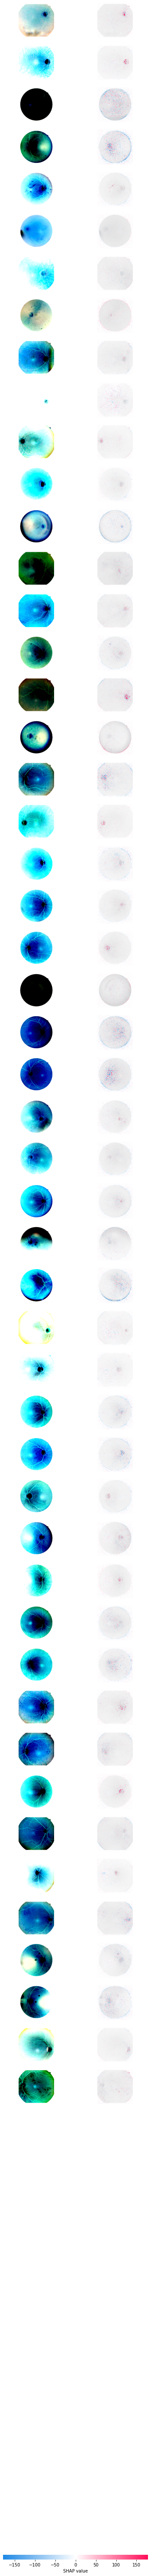

In [96]:
shap.image_plot(swapped_values_img_1, -1 * concat_imgs_img_1[:total_test_samples])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

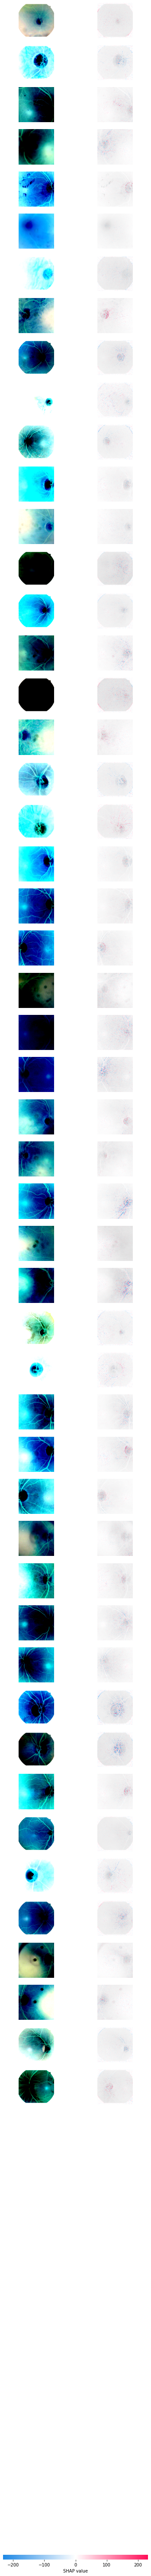

In [97]:
shap.image_plot(swapped_values_img_2, -1 * concat_imgs_img_2[:total_test_samples])

## Only Positive 

In [98]:
indices_train = []
indices_test = []
for i, label in enumerate(sample_train_label):
    if label == 1:
        indices_train.append(i)
        
for i, label in enumerate(sample_test_label):
    if label == 1:
        indices_test.append(i)
        

sample_train__img_shap_1_pos = [sample_train__img_shap_1[i] for i in indices_train]
sample_train__img_shap_2_pos = [sample_train__img_shap_2[i] for i in indices_train]
sample_test__img_shap_1_pos = [sample_test__img_shap_1[i] for i in indices_test]
sample_test__img_shap_2_pos = [sample_test__img_shap_2[i] for i in indices_test]

sample_train__tab_shap_pos = [sample_train__tab_shap[i] for i in indices_train]
sample_test__tab_shap_pos = [sample_test__tab_shap[i] for i in indices_test]

In [99]:

explainer_multi_pos = shap.DeepExplainer(model, [torch.from_numpy(np.stack(sample_train__img_shap_1_pos[:total_train_samples])),
                                                    torch.from_numpy(np.stack(sample_train__img_shap_2_pos[:total_train_samples])),
                                                    torch.from_numpy(np.stack(sample_train__tab_shap_pos[:total_train_samples]))])

In [ ]:
shap_list_pos = []
for i in tqdm(range(total_test_samples)):
    img_1 = torch.from_numpy(np.stack(sample_test__img_shap_1_pos[i]))
    img_2 = torch.from_numpy(np.stack(sample_test__img_shap_2_pos[i]))
    tab = torch.from_numpy(np.stack(sample_test__tab_shap_pos[i]))
    img_1 = img_1[None,:]
    img_2 = img_2[None,:]
    tab = tab[None,:]
    single_shaps_values = explainer_multi_pos.shap_values([img_1,img_2,tab])
    shap_list_pos.append(single_shaps_values)
    if i == len(sample_test__img_shap_1):
        break
    


In [101]:
# 0 img_1
# 1 img_2
# 2 tab
tab_shap_list_pos = []
img_1_shap_list_pos = []
img_2_shap_list_pos = []


for i in range(len(shap_list_pos)):
    tab_shap_list_pos.append(shap_list_pos[i][2])
    img_1_shap_list_pos.append(shap_list_pos[i][0])   
    img_2_shap_list_pos.append(shap_list_pos[i][1]) 

In [102]:
tab_shap_values_pos = np.concatenate(tab_shap_list_pos, axis=0)
img_1_shap_values_pos  = np.concatenate(img_1_shap_list_pos, axis=0)
img_2_shap_values_pos  = np.concatenate(img_2_shap_list_pos, axis=0)

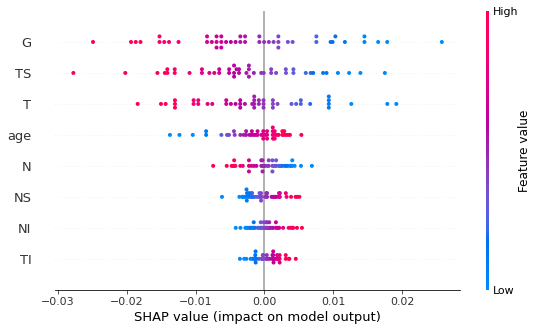

In [103]:
shap.summary_plot(tab_shap_values_pos, np.stack(sample_test__tab_shap_pos[:total_test_samples]), features_name)

In [104]:
swapped_values_img_1_pos = np.swapaxes(np.swapaxes(img_1_shap_values_pos, 1, -1), 1, 2)
swapped_values_img_2_pos = np.swapaxes(np.swapaxes(img_2_shap_values_pos, 1, -1), 1, 2)

In [105]:
concat_imgs_img_1_pos =  np.swapaxes(np.swapaxes(np.stack(sample_test__img_shap_1_pos), 1, -1), 1, 2)
concat_imgs_img_2_pos =  np.swapaxes(np.swapaxes(np.stack(sample_test__img_shap_2_pos), 1, -1), 1, 2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

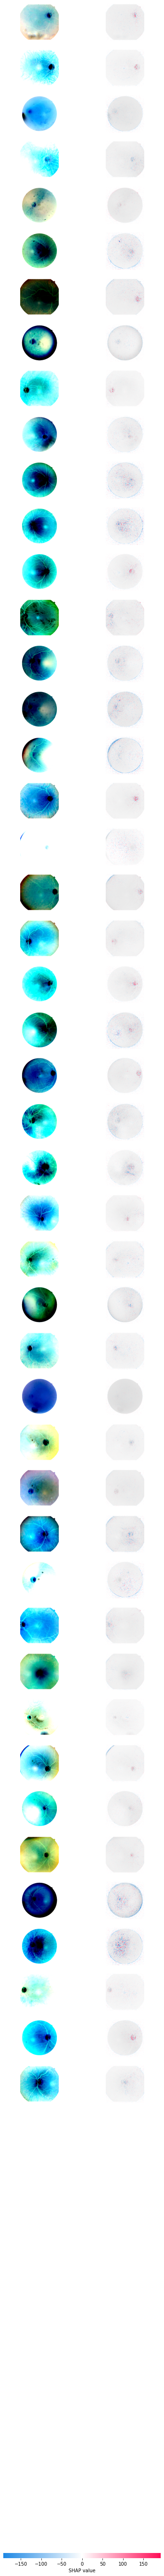

In [106]:
shap.image_plot(swapped_values_img_1_pos, -1 * concat_imgs_img_1_pos[:total_test_samples])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

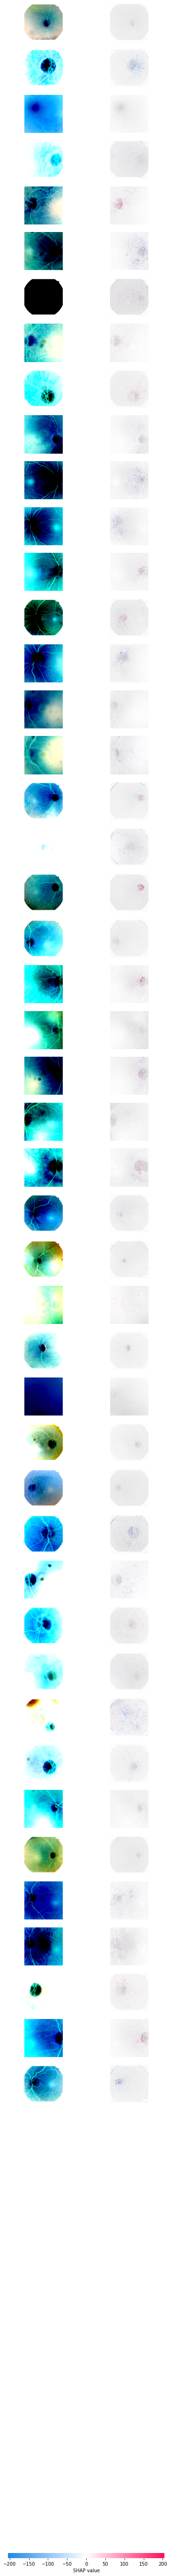

In [107]:
shap.image_plot(swapped_values_img_2_pos, -1 * concat_imgs_img_2_pos[:total_test_samples])